# SQLite | Banco Control #

In [1]:
import sqlite3 as s
import csv

# criação do banco e cursor dos objetos do banco de dados
con = s.connect('controls.db')
cur = con.cursor()

In [2]:
# Criação da tabela despesas
cur.execute("""
    CREATE TABLE despesas(
        id INTEGER PRIMARY KEY,
        data DATE,
        categoria VARCHAR(100),
        descricao VARCHAR(100), 
        valor REAL,
        forma_pagamento VARCHAR(50)
    )
""")

In [3]:
# 1. Abra o arquivo CSV usando a biblioteca csv
path = '/home/rlbarbosa/Projects/sqlite3_analysis/raw/despesas.csv'

with open(path, mode='r', encoding='utf-8') as arquivo:
    leitor = csv.reader(arquivo)
    
    # 2. Pule o cabeçalho se o seu arquivo tiver os nomes das colunas na 1ª linha
    next(leitor) 
    
    # 3. O leitor converte cada linha em uma lista com os valores separados: ["col1", "col2", ...]
    cur.executemany("""
        INSERT INTO despesas
        VALUES (?, ?, ?, ?, ?, ?)
    """, leitor)

con.commit()

### Exploração de dados ###

In [4]:
# Exploração dos dados

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql_query("SELECT * FROM despesas", con)
df.head(10)

,id,data,categoria,descricao,valor,forma_pagamento
0,1,2023-01-02,Lazer,Jogos,129.76,Pix
1,2,2023-01-02,Alimentação,Supermercado,110.30,Cartão de débito
2,3,2023-01-02,Transporte,Aplicativo de transporte,108.26,Dinheiro
3,4,2023-01-02,Serviços,Lavanderia,31.52,Dinheiro
4,5,2023-01-03,Lazer,Streaming,188.50,Pix
5,6,2023-01-04,Educação,Plataforma online,270.33,Dinheiro
6,7,2023-01-05,Transporte,Pedágio,142.49,Dinheiro
7,8,2023-01-05,Serviços,Salão de beleza,218.99,Cartão de crédito
8,9,2023-01-06,Outros,Doação,244.70,Dinheiro
9,10,2023-01-06,Lazer,Bar,255.77,Boleto


In [5]:
# Colunas e registros 
print(f'Na fonte de dados temos {df.shape[1]} colunas e {df.shape[0]} registros')

Na fonte de dados temos 6 colunas e 2200 registros


In [6]:
# Tipagem dos dados 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2200 non-null   int64  
 1   data             2200 non-null   str    
 2   categoria        2200 non-null   str    
 3   descricao        2200 non-null   str    
 4   valor            2200 non-null   float64
 5   forma_pagamento  2200 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 103.3 KB


In [7]:
# Tipagem de dados
df['data'] = pd.to_datetime(df['data'])

In [8]:
# Identificar se há series nulas
df.isnull().any().any()

np.False_

In [9]:
# verificando a tipagem de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               2200 non-null   int64         
 1   data             2200 non-null   datetime64[us]
 2   categoria        2200 non-null   str           
 3   descricao        2200 non-null   str           
 4   valor            2200 non-null   float64       
 5   forma_pagamento  2200 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 103.3 KB


### 1. Análise de centro de cursos ###

In [10]:
# criação da serie ano
df['ano'] = df['data'].dt.year

In [11]:
df1 = pd.DataFrame(df.groupby('categoria')['valor'].sum())

valor_total = df['valor'].sum()
df1['percent'] = round(df1['valor']/valor_total, 3)

df1.sort_values('valor', ascending=False)

,valor,percent
categoria,,
Moradia,334713.62,0.450
Saúde,94354.01,0.127
Educação,93563.81,0.126
Alimentação,57246.29,0.077
Serviços,37426.06,0.050
Vestuário,37291.77,0.050
Lazer,37150.47,0.050
Transporte,34068.29,0.046
Outros,17307.40,0.023


Como podemos verificar nos valores acima, as despesas por categorias se concentra em "Moradia" com 3347713.62 (45%), e Saúde com "94354.01" (13%).

### 2. Conciliação de meio de pagamento ###

In [13]:
df2 = pd.DataFrame(df['forma_pagamento'].value_counts())
df2 = df2.rename(columns={'count': 'qtde'})
df2['parcent'] = round(df2['qtde']/len(df), 3)

df2

,qtde,parcent
forma_pagamento,,
Pix,468,0.213
Dinheiro,459,0.209
Cartão de débito,437,0.199
Boleto,428,0.195
Cartão de crédito,408,0.185


A distribuição de despesas em valor absoluto e representação está concentrado na forma de pagamento pix com 21,3% e dinheiro em segundo lugar com 20,9%.

### 3. Fluxo de Caixa Diário ###

In [14]:
# Filtro da primeira semana de janeiro de 2023
first_week = df[ (df['data'] >= '2023-01-01') & (df['data'] <= '2023-01-07')].sort_values('data', ascending=True)

df3 = pd.DataFrame(first_week.groupby('data')['valor'].sum())
display(df3)

,valor
data,
2023-01-02,379.84
2023-01-03,188.50
2023-01-04,270.33
2023-01-05,361.48
2023-01-06,1290.05
2023-01-07,3125.43


In [15]:
df3['valor'].sum()

np.float64(5615.629999999999)

O total de saída referente a primeira semana de de janeiro de 2023 é de $5615.6299.

### 4. Ticket Médio por Transação ###

In [16]:
gastos = df['valor'].sum()
qtde = len(df)

tiketMedio = gastos/qtde

print(f'O Tiket Médio total das das transações em todo o período é de {tiketMedio}.')

O Tiket Médio total das das transações em todo o período é de 337.7826.


In [46]:
# Agora por tipo de transação...

for f in df['forma_pagamento'].unique():

    g = df[df['forma_pagamento'] == f].valor.sum()
    qt = df[df['forma_pagamento'] == f].id.count()
    tk = round(g/qt, 2)

    #print(f, '-', round(g, 2))
    #print(f, '-', round(qt, 2))
    print(f, ':', tk)

Pix : 326.37
Cartão de débito : 349.41
Dinheiro : 338.49
Cartão de crédito : 326.04
Boleto : 348.83


### 5. Curva ABS de Gastos ###

In [52]:
amostra = pd.DataFrame(df.groupby(['categoria', 'descricao'])['valor'].sum())
amostra.sort_values('valor', ascending=False).head(3)

valor
categoria descricao                 
Moradia   Aluguel           73535.99
          Gás               62574.37
          Energia elétrica  55410.72

In [58]:
# Acrescentar a serie acumulado com os parametros abaixo: 

df5 = pd.DataFrame(df.groupby(['categoria', 'descricao'])['valor'].sum())
valor_total = df['valor'].sum()

df5_2 = df5.sort_values('valor', ascending=False)
df5_2['percent'] = round(df5_2['valor']/valor_total, 3)
df5_2['accumulated'] = df5_2['percent'].cumsum() # Accumulated

# Uso da funcao .apply para comparar a condicional criada em no 'def'. 
var = df5_2['accumulated']

def curva(var):
    
    if var <= 0.10:
        return 'A'
    elif var > 0.10 and var <= 0.19:
        return 'B'
    else: 
        return 'C'

df5_2['classe'] = df5_2['accumulated'].apply(curva)
df5_2.head(3)


valor  percent  accumulated classe
categoria descricao                                              
Moradia   Aluguel           73535.99    0.099        0.099      A
          Gás               62574.37    0.084        0.183      B
          Energia elétrica  55410.72    0.075        0.258      C

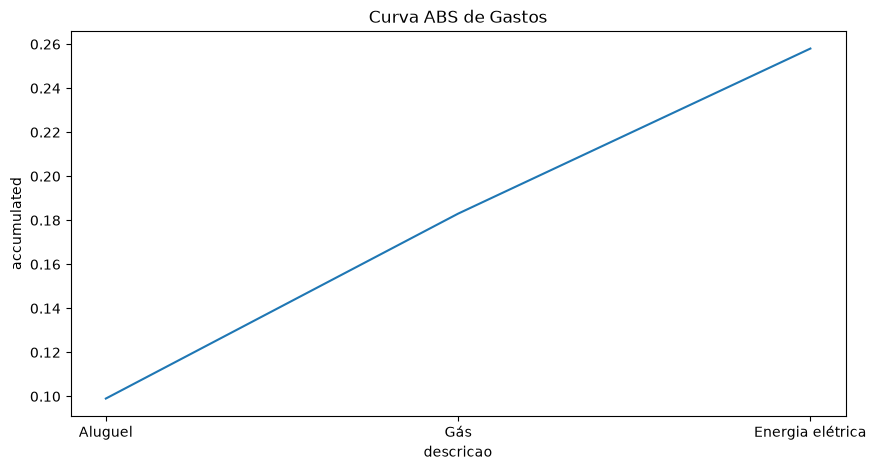

In [60]:
plt.figure(figsize=(10, 5)) # -> Defini o comportamento do grafico
sns.lineplot(data=df5_2.head(3), x='descricao', y='accumulated')

plt.title('Curva ABS de Gastos')
plt.show()

Observando o grafico acima, temos as representações a baixo:
* 80% - {Moradia - Saude - Educacao - Alimentacao},
* 15% - {Servicos - Vestuario - Lazer} 
* 5% - {Transporte/ Outros}